data cleaning

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns



In [3]:
df=pd.read_csv("D:/week 8/data/raw data.csv")

In [5]:
df

,brokered_by,status,price,bed,bath,acre_lot,street,city,state,zip_code,house_size,prev_sold_date
0,103378.0,for_sale,105000.0,3.0,2.0,0.12,1962661.0,Adjuntas,Puerto Rico,601.0,920.0,NaN
1,52707.0,for_sale,80000.0,4.0,2.0,0.08,1902874.0,Adjuntas,Puerto Rico,601.0,1527.0,NaN
2,103379.0,for_sale,67000.0,2.0,1.0,0.15,1404990.0,Juana Diaz,Puerto Rico,795.0,748.0,NaN
3,31239.0,for_sale,145000.0,4.0,2.0,0.10,1947675.0,Ponce,Puerto Rico,731.0,1800.0,NaN
4,34632.0,for_sale,65000.0,6.0,2.0,0.05,331151.0,Mayaguez,Puerto Rico,680.0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
2226377,23009.0,sold,359900.0,4.0,2.0,0.33,353094.0,Richland,Washington,99354.0,3600.0,2022-03-25
2226378,18208.0,sold,350000.0,3.0,2.0,0.10,1062149.0,Richland,Washington,99354.0,1616.0,2022-03-25
2226379,76856.0,sold,440000.0,6.0,3.0,0.50,405677.0,Richland,Washington,99354.0,3200.0,2022-03-24
2226380,53618.0,sold,179900.0,2.0,1.0,0.09,761379.0,Richland,Washington,99354.0,933.0,2022-03-24


In [6]:


df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2226382 entries, 0 to 2226381
Data columns (total 12 columns):
 #   Column          Dtype  
---  ------          -----  
 0   brokered_by     float64
 1   status          object 
 2   price           float64
 3   bed             float64
 4   bath            float64
 5   acre_lot        float64
 6   street          float64
 7   city            object 
 8   state           object 
 9   zip_code        float64
 10  house_size      float64
 11  prev_sold_date  object 
dtypes: float64(8), object(4)
memory usage: 203.8+ MB


In [7]:
df.describe()

,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size
count,2.221849e+06,2.224841e+06,1.745065e+06,1.714611e+06,1.900793e+06,2.215516e+06,2.226083e+06,1.657898e+06
mean,5.293989e+04,5.241955e+05,3.275841e+00,2.496440e+00,1.522303e+01,1.012325e+06,5.218668e+04,2.714471e+03
std,3.064275e+04,2.138893e+06,1.567274e+00,1.652573e+00,7.628238e+02,5.837635e+05,2.895408e+04,8.081635e+05
min,0.000000e+00,0.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.000000e+00
25%,2.386100e+04,1.650000e+05,3.000000e+00,2.000000e+00,1.500000e-01,5.063128e+05,2.961700e+04,1.300000e+03
50%,5.288400e+04,3.250000e+05,3.000000e+00,2.000000e+00,2.600000e-01,1.012766e+06,4.838200e+04,1.760000e+03
75%,7.918300e+04,5.500000e+05,4.000000e+00,3.000000e+00,9.800000e-01,1.521173e+06,7.807000e+04,2.413000e+03
max,1.101420e+05,2.147484e+09,4.730000e+02,8.300000e+02,1.000000e+05,2.001357e+06,9.999900e+04,1.040400e+09


<Axes: >

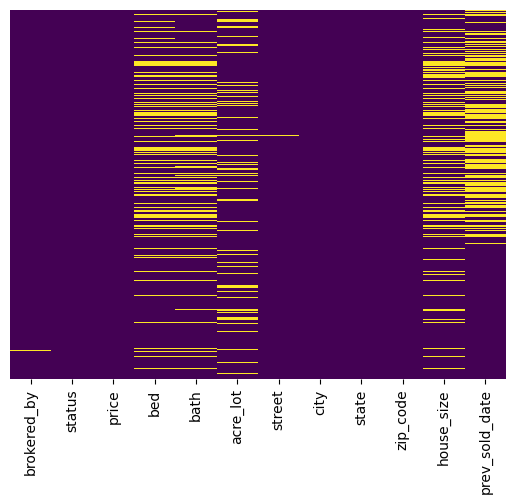

In [8]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

In [9]:
null_count = df[df["house_size"].isna()]
print("Number of null values in house_size:", null_count)

Number of null values in house_size:          brokered_by    status     price  bed  bath  acre_lot     street  \
4            34632.0  for_sale   65000.0  6.0   2.0      0.05   331151.0   
43           80224.0  for_sale  380000.0  NaN   NaN     18.45  1855421.0   
59           46019.0  for_sale   35000.0  NaN   NaN      0.88  1234597.0   
60           52464.0  for_sale   58000.0  NaN   NaN      0.21  1966337.0   
61           46019.0  for_sale   85000.0  NaN   NaN     21.08  1188097.0   
...              ...       ...       ...  ...   ...       ...        ...   
2226314     108356.0      sold  275000.0  NaN   NaN      1.61  1137775.0   
2226316     108356.0      sold  275000.0  NaN   NaN      1.77  1309786.0   
2226317     108356.0      sold  300000.0  NaN   NaN      1.63  1668435.0   
2226319      23062.0      sold  189000.0  NaN   NaN      0.54  1948334.0   
2226329     105917.0      sold  199000.0  2.0   1.0      1.00  1582109.0   

                city        state  zip_code  house

In [10]:
df['house_size'] = df['house_size'].fillna(0)  

In [11]:
df["bed"].mean()

3.2758407279958055

In [12]:

df['bed'] = df['bed'].fillna(3.275)

In [13]:
df["bath"].mean()

2.496440300452989

In [14]:
df['bath']=df["bath"].fillna(2.496440300452989)

In [15]:
df["prev_sold_date"] = pd.to_datetime(df["prev_sold_date"], errors='coerce')
mean_date = df["prev_sold_date"].mean()
print(mean_date)

2017-08-16 04:21:19.095814912


In [16]:
df["prev_sold_date"]=df["prev_sold_date"].fillna(2017-8-16)

In [17]:
df["acre_lot"].mean()

15.223027446965554

In [18]:
df["acre_lot"]=df["acre_lot"].fillna(15.223027446965554)

In [19]:
df["brokered_by"].mean()

52939.89328662749

In [20]:
df["brokered_by"]=df["brokered_by"].fillna(52939.89328662749)

In [21]:
df["street"].mean()

1012324.9206654341

In [22]:
df["street"]=df["street"].fillna(1012324.9206654341)

<Axes: >

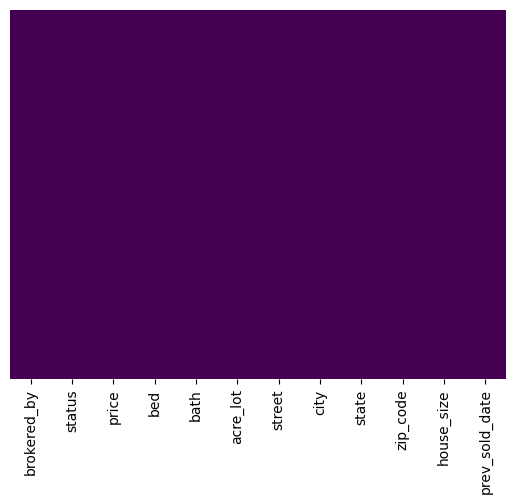

In [23]:
sns.heatmap(df.isnull(),yticklabels=False,cbar=False,cmap='viridis')

C:\Users\Kaif\AppData\Local\Temp\ipykernel_24632\1299005234.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxenplot(y="price", x="state", data=df, palette="deep")


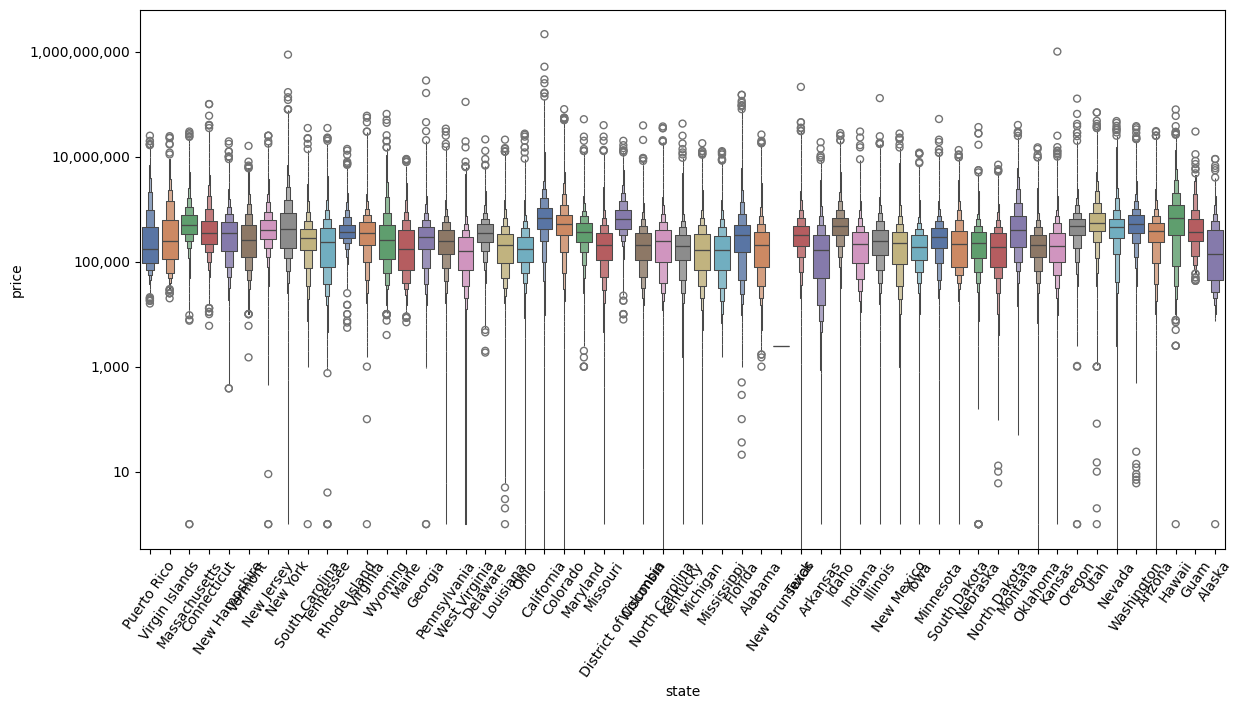

In [24]:
import matplotlib.ticker as ticker

plt.figure(figsize=(14, 7))
sns.boxenplot(y="price", x="state", data=df, palette="deep")
plt.xticks(rotation=55)
plt.yscale('log')

# Format y-axis ticks to plain numbers
plt.gca().yaxis.set_major_formatter(ticker.ScalarFormatter())
plt.gca().yaxis.set_minor_formatter(ticker.NullFormatter())  # Optional: hide minor ticks
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f'{int(x):,}'))
plt.show()

In [25]:
df["state"].unique()

array(['Puerto Rico', 'Virgin Islands', 'Massachusetts', 'Connecticut',
       'New Hampshire', 'Vermont', 'New Jersey', 'New York',
       'South Carolina', 'Tennessee', 'Rhode Island', 'Virginia',
       'Wyoming', 'Maine', 'Georgia', 'Pennsylvania', 'West Virginia',
       'Delaware', 'Louisiana', 'Ohio', 'California', 'Colorado',
       'Maryland', 'Missouri', 'District of Columbia', 'Wisconsin',
       'North Carolina', 'Kentucky', 'Michigan', 'Mississippi', 'Florida',
       'Alabama', 'New Brunswick', nan, 'Texas', 'Arkansas', 'Idaho',
       'Indiana', 'Illinois', 'New Mexico', 'Iowa', 'Minnesota',
       'South Dakota', 'Nebraska', 'North Dakota', 'Montana', 'Oklahoma',
       'Kansas', 'Oregon', 'Utah', 'Nevada', 'Washington', 'Arizona',
       'Hawaii', 'Guam', 'Alaska'], dtype=object)

In [26]:

new_york=df[df["state"]=="New York"]

In [27]:
bednewyor = new_york.copy()
bednewyor["bed"] = pd.to_numeric(bednewyor["bed"], errors="coerce")
bednewyor = bednewyor.sort_values(by="bed")

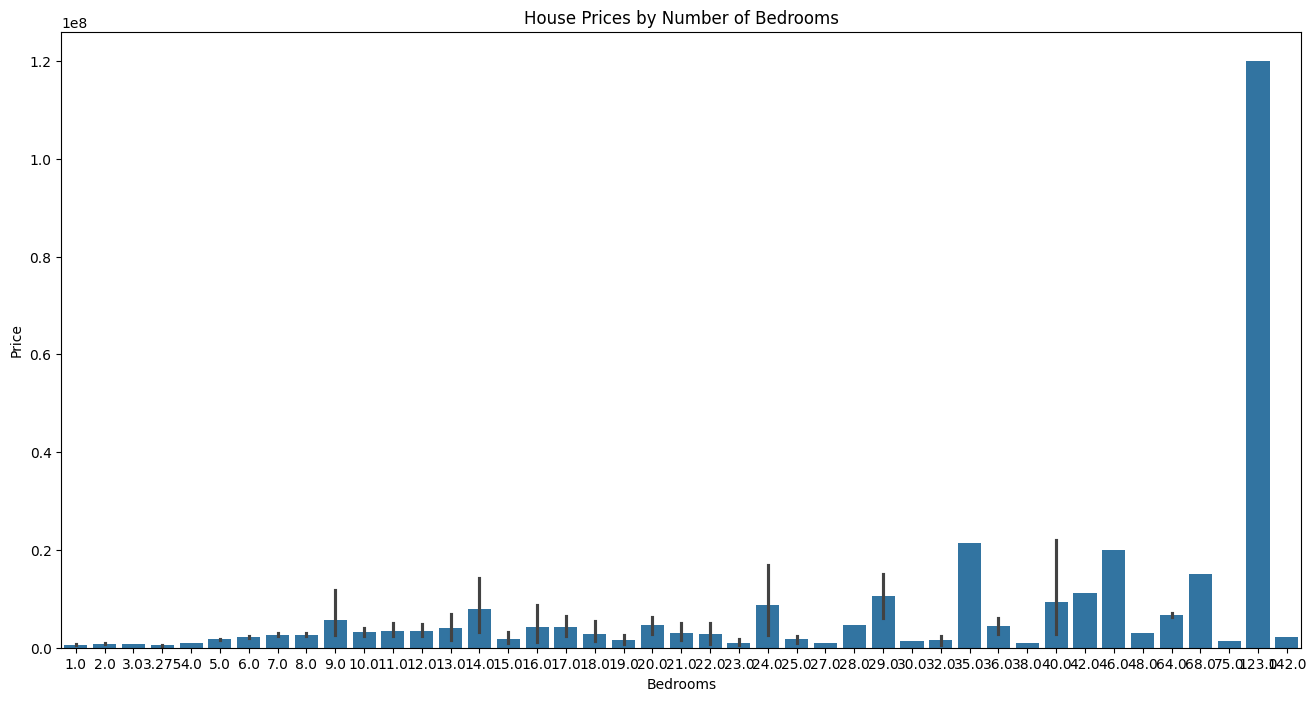

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

plt.figure(figsize=(16, 8))  
sns.barplot(
    y="price", 
    x="bed", 
    data=bednewyor,  
)



plt.ylabel("Price")
plt.xlabel("Bedrooms")
plt.title("House Prices by Number of Bedrooms")
plt.show()

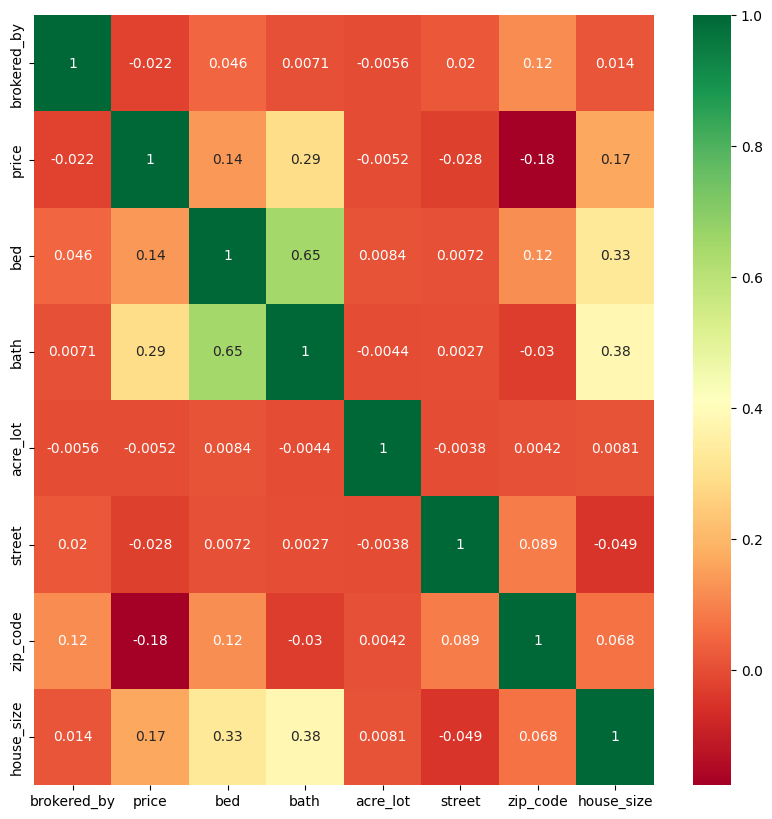

In [29]:
plt.figure(figsize=(10,10))
sns.heatmap(new_york.select_dtypes(include='number').corr(), annot=True, cmap="RdYlGn")
plt.show()

In [30]:
nyc=df[df["city"]=="New York City"]

In [31]:
nyc.describe()

,brokered_by,price,bed,bath,acre_lot,street,zip_code,house_size
count,12634.000000,1.263400e+04,12634.000000,12634.000000,12634.000000,1.263400e+04,12634.000000,12634.000000
mean,36268.518366,2.266022e+06,2.454241,2.132986,12.466265,8.854213e+05,10445.592845,1106.761991
std,24546.703302,4.176101e+06,2.094567,1.949035,7.976343,4.780587e+05,563.264535,1779.684850
min,402.000000,1.000000e+00,1.000000,1.000000,0.000000,6.106000e+03,10001.000000,0.000000
25%,23592.000000,6.650000e+05,1.000000,1.000000,15.223027,5.252348e+05,10019.000000,0.000000
50%,24196.000000,1.195000e+06,2.000000,2.000000,15.223027,9.275850e+05,10032.000000,750.500000
75%,41924.000000,2.298497e+06,3.000000,3.000000,15.223027,1.231092e+06,11205.000000,1434.750000
max,109331.000000,1.690000e+08,123.000000,123.000000,625.000000,1.989631e+06,11694.000000,94263.000000


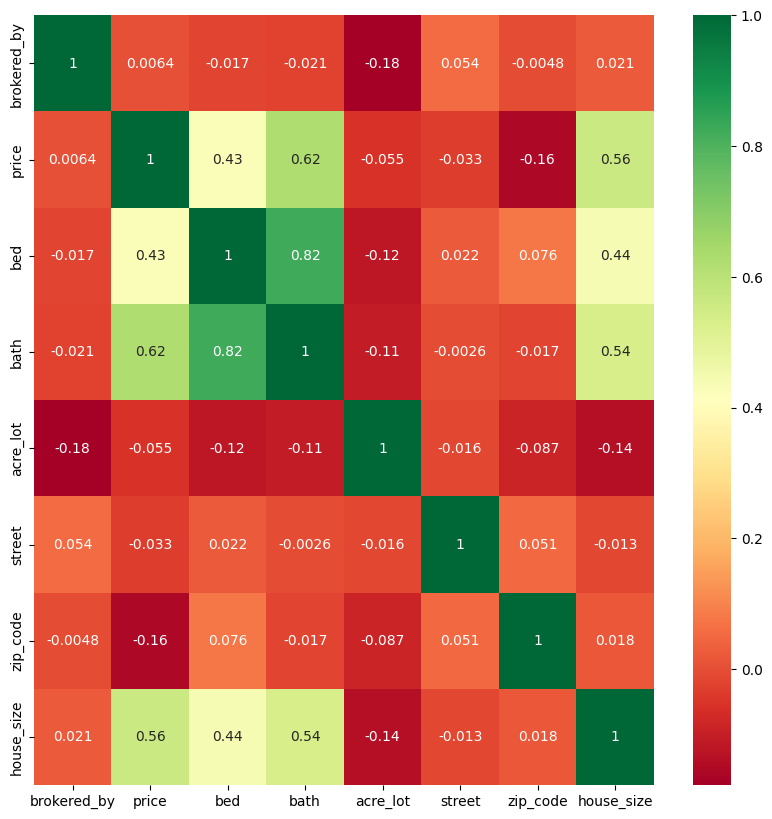

In [32]:
plt.figure(figsize=(10,10))
sns.heatmap(nyc.select_dtypes(include='number').corr(), annot=True, cmap="RdYlGn")
plt.show()

<Figure size 1500x2000 with 0 Axes>

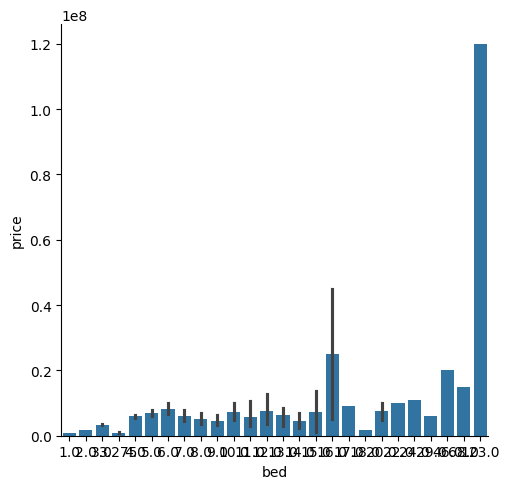

<Figure size 1500x2000 with 0 Axes>

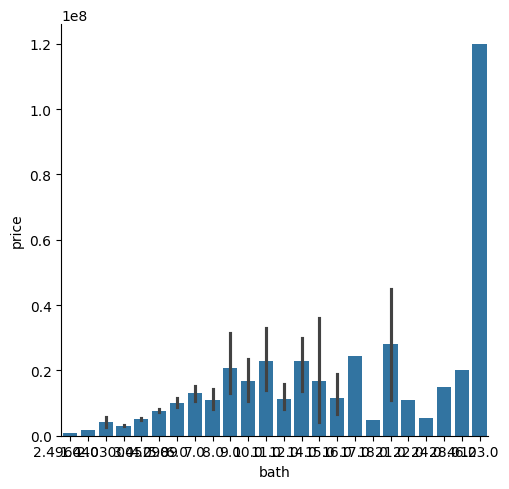

<Figure size 1500x2000 with 0 Axes>

In [33]:
sns.catplot(x="bed", y="price", kind='bar', data=nyc) 
plt.figure(figsize=(15,20))
sns.catplot(x="bath", y="price", kind='bar', data=nyc) 
plt.figure(figsize=(15,20))


<Figure size 10000x2000 with 0 Axes>

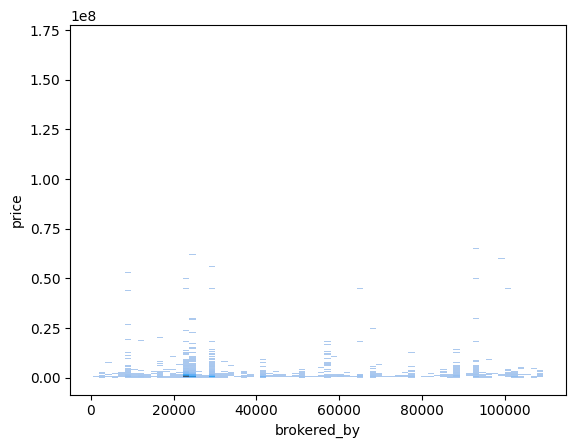

<Figure size 10000x2000 with 0 Axes>

In [34]:
sns.histplot(x="brokered_by", y="price", data=nyc) 
plt.figure(figsize=(100,20))

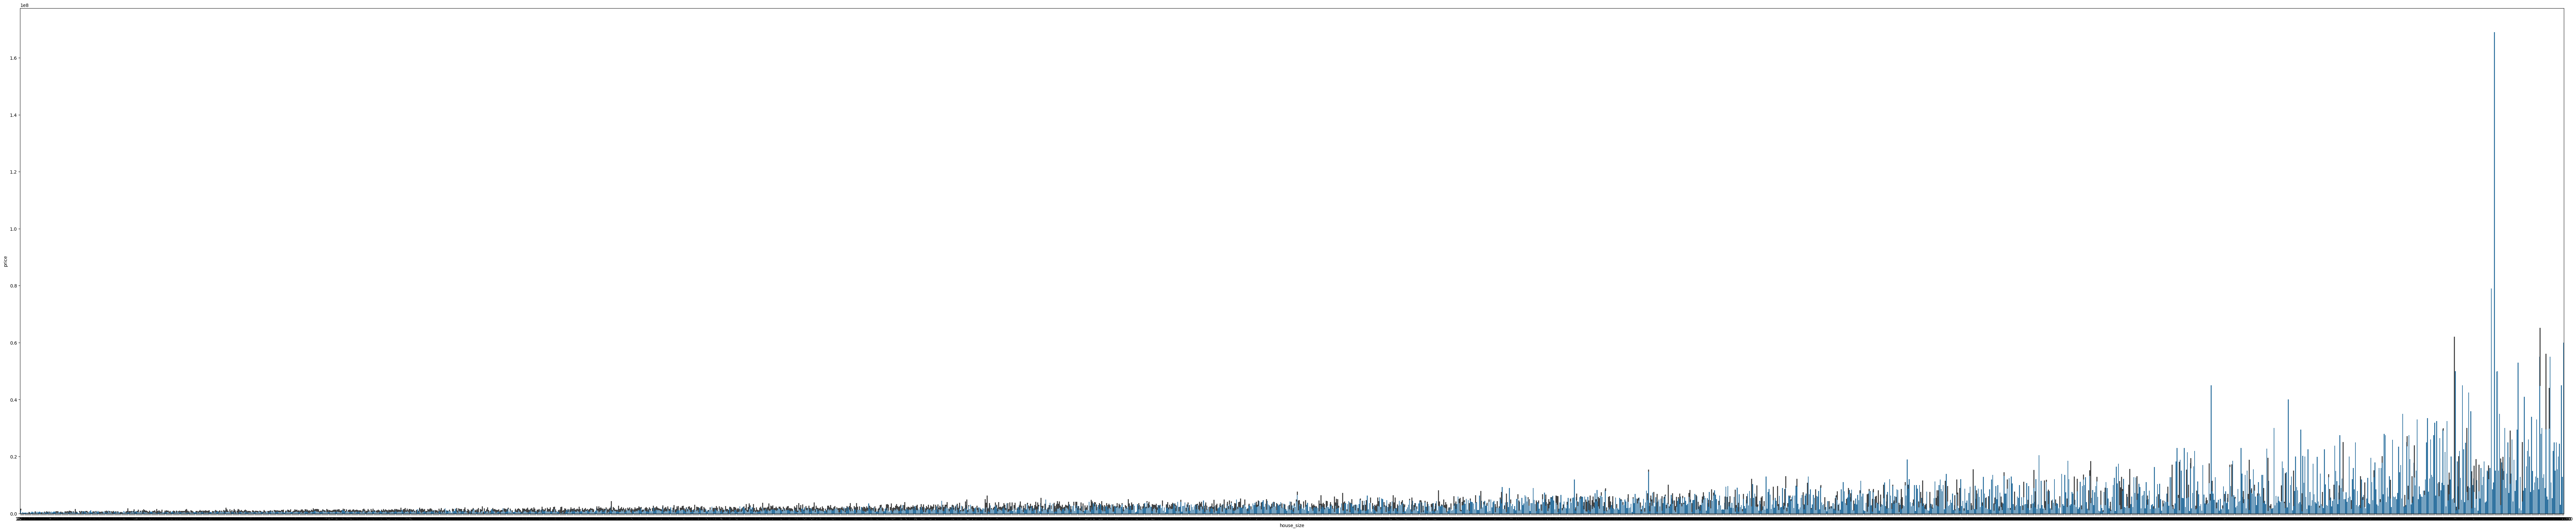

In [35]:
plt.figure(figsize=(100,20))
sns.barplot(x="house_size",y="price",data=nyc)
plt.show()

In [36]:
import scipy.stats as stats


groups = [group["price"].values for name, group in nyc.groupby("bed")]


f_stat, p_val = stats.f_oneway(*groups)

print("ANOVA F-statistic:", f_stat)
print("p-value:", p_val)

if p_val < 0.05:
    print("Result: Significant difference in average prices across bedroom counts.")
else:
    print("Result: No significant difference in average prices across bedroom counts.")

ANOVA F-statistic: 194.04006104027624
p-value: 0.0
Result: Significant difference in average prices across bedroom counts.


In [37]:
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tukey = pairwise_tukeyhsd(endog=nyc["price"], groups=nyc["bed"], alpha=0.05)
print(tukey)

c:\ProgramData\anaconda3\envs\myenv\Lib\site-packages\scipy\integrate\_quadpack_py.py:1272: IntegrationWarning: The integral is probably divergent, or slowly convergent.
  quad_r = quad(f, low, high, args=args, full_output=self.full_output,


          Multiple Comparison of Means - Tukey HSD, FWER=0.05           
group1 group2    meandiff    p-adj      lower          upper      reject
------------------------------------------------------------------------
   1.0    2.0    839426.6647    0.0    541575.8428   1137277.4866   True
   1.0    3.0   2503252.5374    0.0   2136989.7354   2869515.3395   True
   1.0  3.275      5343.0943    1.0   -406770.5443     417456.733  False
   1.0    4.0    5097371.328    0.0    4576349.424    5618393.232   True
   1.0    5.0   6050476.3815    0.0   5352237.4492   6748715.3138   True
   1.0    6.0   7217689.0721    0.0   6398770.3728   8036607.7714   True
   1.0    7.0   5105591.4164    0.0   3795302.2426   6415880.5903   True
   1.0    8.0   4224423.5419    0.0   2748890.1239   5699956.9599   True
   1.0    9.0   3679796.8086    0.0   1395727.5809   5963866.0362   True
   1.0   10.0    6362688.936    0.0   4112179.3616   8613198.5105   True
   1.0   11.0   4993442.6419    0.0   1720151.5286 

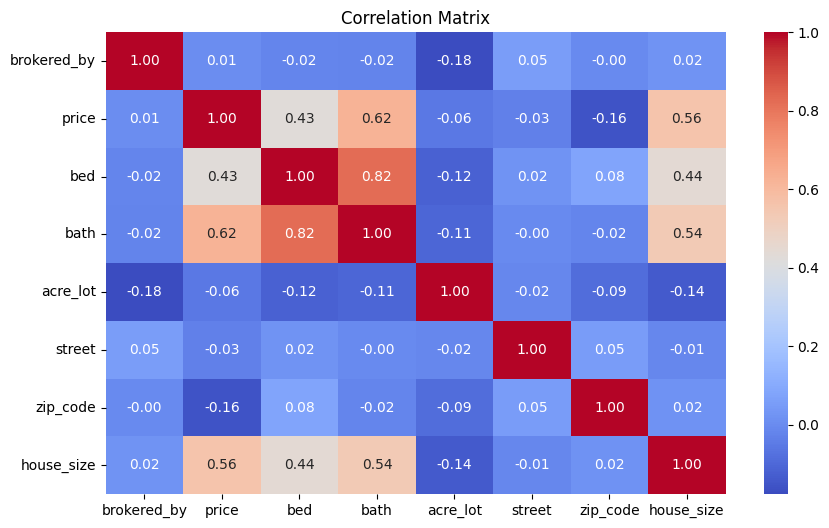

In [38]:


# Compute correlation matrix
corr = nyc.corr(numeric_only=True)

plt.figure(figsize=(10, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix")
plt.show()

In [40]:

import statsmodels.api as sm
import numpy as np
nyc["log_price"] = np.log(nyc["price"])
X = nyc[["bed", "bath", "acre_lot","street","house_size","brokered_by","zip_code"]]
y = nyc["log_price"]
X = sm.add_constant(X)
model = sm.OLS(y, X).fit()
print(model.summary())

                            OLS Regression Results                            
Dep. Variable:              log_price   R-squared:                       0.508
Model:                            OLS   Adj. R-squared:                  0.508
Method:                 Least Squares   F-statistic:                     1866.
Date:                Sat, 24 Jan 2026   Prob (F-statistic):               0.00
Time:                        21:37:39   Log-Likelihood:                -12935.
No. Observations:               12634   AIC:                         2.589e+04
Df Residuals:                   12626   BIC:                         2.595e+04
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          16.4988      0.115    143.126      

C:\Users\Kaif\AppData\Local\Temp\ipykernel_24632\2157086141.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  nyc["log_price"] = np.log(nyc["price"])
